In [1]:
import pandas as pd

df = pd.read_csv("../data/insurance.csv")

df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


(1338, 7)

In [2]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [3]:
df.describe(include='object')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [5]:
df.shape

(1338, 7)

In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [9]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (1338, 7)
After: (1337, 7)


In [11]:
df.to_csv("../data/insurance_cleaned.csv", index=False)

# Exploratory Data Analysis (EDA)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Charges Distribution

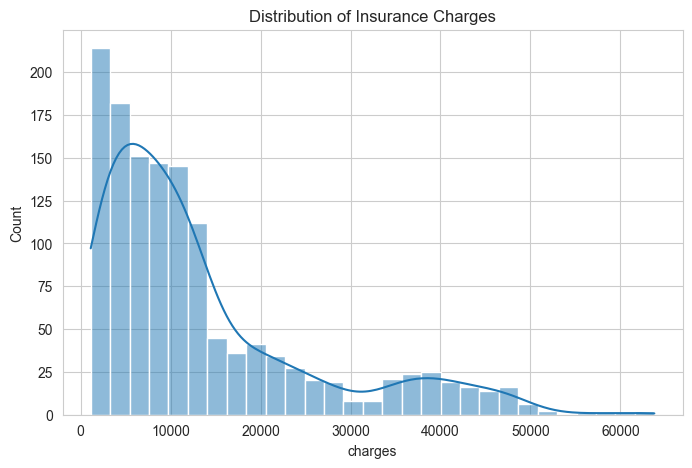

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["charges"], kde=True)

plt.title("Distribution of Insurance Charges")
plt.show()

Insurance charges are right-skewed, with most individuals having lower medical costs and a small number having very high expenses.

Age vs Charges

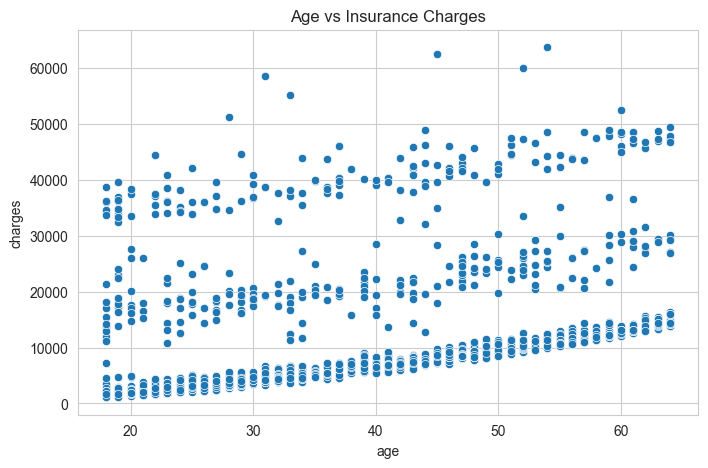

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="age",
    y="charges",
    data=df
)

plt.title("Age vs Insurance Charges")
plt.show()

Insurance charges generally increase with age.

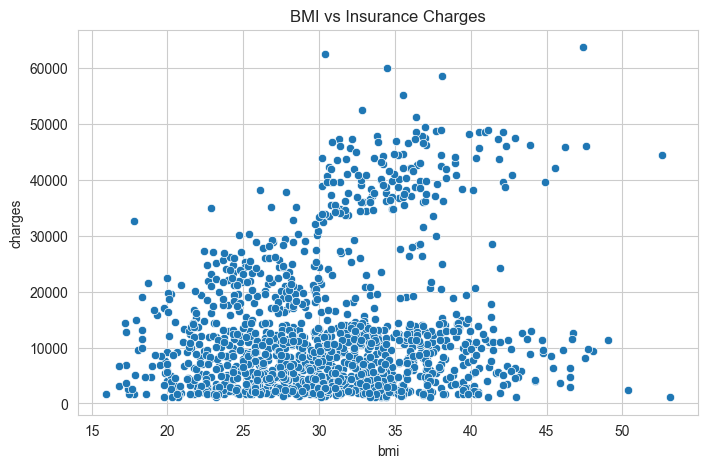

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges"
)

plt.title("BMI vs Insurance Charges")
plt.show()

Individuals with higher BMI values tend to have higher insurance charges, although the relationship is weaker than age and smoking status.

Smoker vs Charges

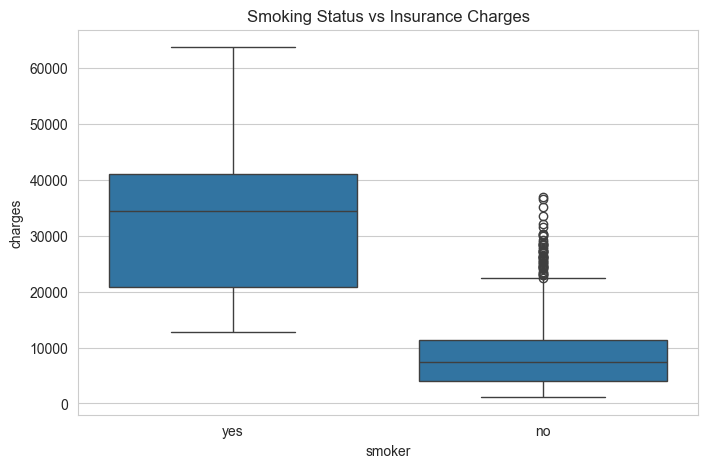

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="smoker",
    y="charges"
)

plt.title("Smoking Status vs Insurance Charges")
plt.show()

mokers have substantially higher insurance charges compared to non-smokers, indicating that smoking is a major cost-driving factor.

Region vs Charges

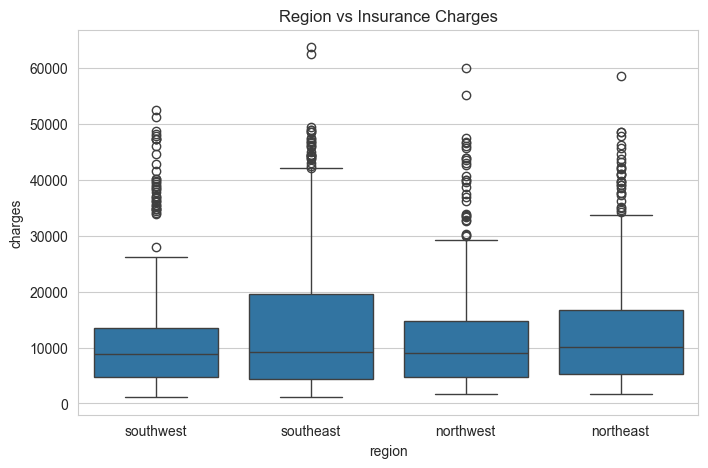

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="region",
    y="charges"
)

plt.title("Region vs Insurance Charges")
plt.show()

Healthcare charges vary slightly across regions, but regional differences are much smaller than the impact of smoking status.

Correlation Heatmap

In [18]:
temp = df.copy()

temp["sex"] = temp["sex"].map({
    "male": 1,
    "female": 0
})

temp["smoker"] = temp["smoker"].map({
    "yes": 1,
    "no": 0
})

temp = pd.get_dummies(
    temp,
    columns=["region"],
    drop_first=True
)

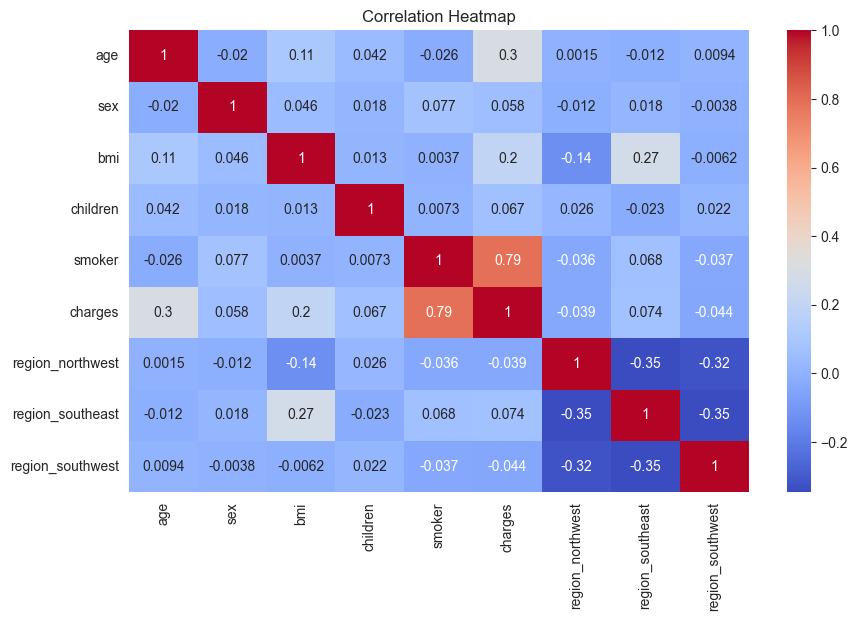

In [19]:
plt.figure(figsize=(10,6))

sns.heatmap(
    temp.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Outlier Analysis.

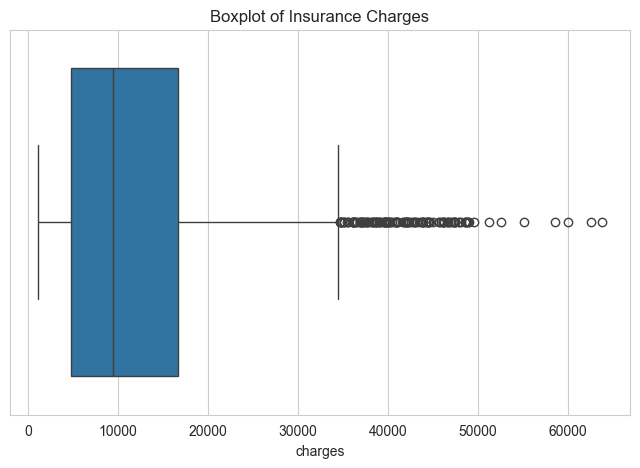

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["charges"])

plt.title("Boxplot of Insurance Charges")
plt.show()

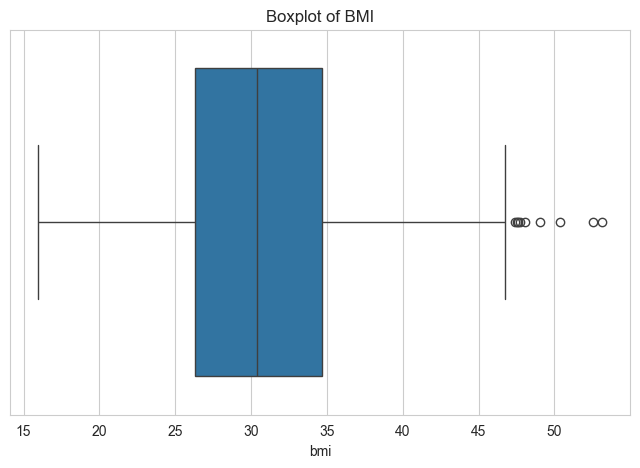

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["bmi"])

plt.title("Boxplot of BMI")
plt.show()

# EDA Summary :
No missing values found.
One duplicate record removed.
Charges are right-skewed.
Age positively impacts charges.
BMI moderately impacts charges.
Smoking is the strongest cost-driving factor.
Region has limited impact.
Outliers exist in charges and BMI but are retained because they represent real high-cost patients and are important for insurance prediction.

Outliers were detected in the BMI and charges variables. These observations were retained because they represent genuine variations in healthcare costs and patient characteristics. Removing them could reduce the model's ability to predict high-cost cases accurately.

Preprocessing + Feature Engineering + Train-Test Split

In [22]:
df_model = df.copy()

Encode Categorical Variables

In [23]:
df_model[['sex','smoker','region']].head()

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest


In [24]:
df_model = pd.get_dummies(
    df_model,
    columns=['sex','smoker','region'],
    drop_first=True
)

In [25]:
df_model.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


# Feature Engineering

In [26]:
df_model['bmi_age_interaction'] = (
    df_model['bmi'] * df_model['age']
)

Why?

Higher BMI + Higher Age often increases health risk.

In [27]:
df_model.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_age_interaction
0,19,27.900,0,16884.92400,False,True,False,False,True,530.100
1,18,33.770,1,1725.55230,True,False,False,True,False,607.860
2,28,33.000,3,4449.46200,True,False,False,True,False,924.000
3,33,22.705,0,21984.47061,True,False,True,False,False,749.265
4,32,28.880,0,3866.85520,True,False,True,False,False,924.160


# Feature Selection

In [28]:
X = df_model.drop('charges', axis=1)

y = df_model['charges']

In [29]:
print(X.shape)
print(y.shape)

(1337, 9)
(1337,)


# Train-Test Split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
print(X_train.shape)
print(X_test.shape)

(1069, 9)
(268, 9)


Feature Scaling (Only for Linear Regression)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [33]:
df_model.to_csv(
    "../data/insurance_processed.csv",
    index=False
)

In [36]:
X_test.shape

(268, 9)